In [1]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('data.csv')

In [2]:
# Drop the empty column at the end if it exists
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

In [3]:
# Display the first 5 rows
print("Data loaded successfully! Here are the first few rows:")
print(df.head())

Data loaded successfully! Here are the first few rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ... 

In [4]:
# Show summary information about the dataset
print("\nDataset Summary:")
print(df.info())


Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimete

In [5]:
import pandas as pd

# 1. Load the dataset
file_path = 'data.csv'
df = pd.read_csv(file_path)

print("Original shape:", df.shape)

Original shape: (569, 33)


In [6]:
# 2. Remove the empty trailing column ('Unnamed: 32')
# This column usually appears due to an extra trailing comma in the CSV lines
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])
    print("-> Removed empty column 'Unnamed: 32'")

-> Removed empty column 'Unnamed: 32'


In [7]:
# 3. Drop the 'id' column
# Unique identifiers do not carry predictive power for analysis or ML modeling
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("-> Removed 'id' column")

-> Removed 'id' column


In [8]:
# 4. Check and handle missing values
# (This dataset doesn't have missing values in other columns, but good to include)
missing_summary = df.isnull().sum()
if missing_summary.sum() > 0:
    print("-> Found missing values. Dropping rows with missing entries...")
    df = df.dropna()
else:
    print("-> No missing values found in numeric columns.")

-> No missing values found in numeric columns.


In [9]:
# 5. Check and handle duplicate rows
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"-> Found {duplicate_count} duplicate rows. Removing duplicates...")
    df = df.drop_duplicates()
else:
    print("-> No duplicate rows found.")

-> No duplicate rows found.


In [10]:
# Mapping 'M' (Malignant) to 1 and 'B' (Benign) to 0
if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
    print("-> Encoded 'diagnosis' column ('M' -> 1, 'B' -> 0)")

print("Cleaned shape:", df.shape)

-> Encoded 'diagnosis' column ('M' -> 1, 'B' -> 0)
Cleaned shape: (569, 31)


In [11]:
# 7. Save the cleaned dataset to a new CSV file
cleaned_file_path = 'cleaned_data.csv'
df.to_csv(cleaned_file_path, index=False)
print(f"-> Cleaned data successfully saved to '{cleaned_file_path}'")

# Display a preview of the cleaned data
print("\nFirst 5 rows of cleaned data:")
print(df.head())

-> Cleaned data successfully saved to 'cleaned_data.csv'

First 5 rows of cleaned data:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radiu

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load data
df = pd.read_csv('data.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

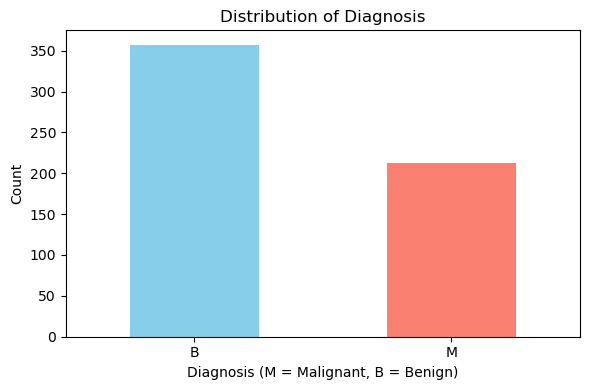

In [14]:
# 1. Class Distribution
plt.subplots(figsize=(6, 4))
df['diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('diagnosis_distribution.png')
plt.show()

In [17]:
# 2. Correlation Heatmap for mean features
mean_features = [col for col in df.columns if '_mean' in col] + ['diagnosis']
# Temporary numeric conversion for correlation
corr_df = df.copy()
corr_df['diagnosis'] = corr_df['diagnosis'].map({'M': 1, 'B': 0})
corr_matrix = corr_df[mean_features].corr()

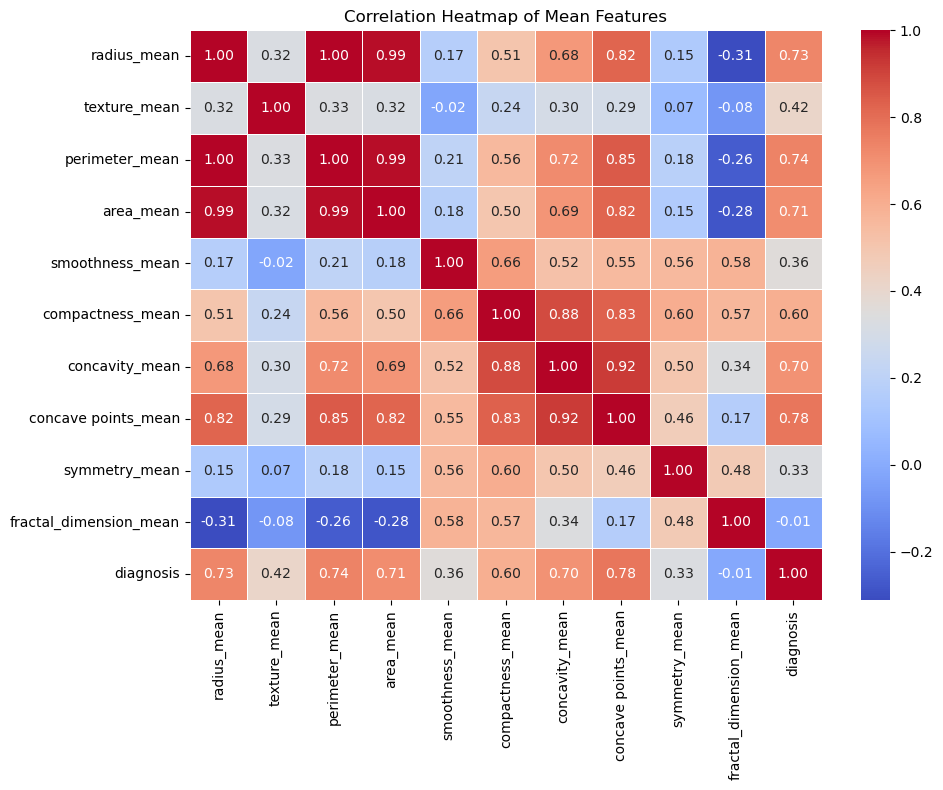

In [18]:
plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Mean Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [22]:
# Load and clean data
df = pd.read_csv('data.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])
if 'id' in df.columns:
    df = df.drop(columns=['id'])